# MetaARIMA vs AutoARIMA

This notebook compares **MetaARIMA** (meta-learned ARIMA selection) with **AutoARIMA** (statsforecast) on the M3 Monthly dataset.

**MetaARIMA** uses a pre-trained meta-learner (trained on M4 Monthly) to shortlist promising ARIMA configurations, then picks the best by AICc via successive halving. This makes it faster than exhaustive AutoARIMA while aiming for competitive accuracy.

Outline:
1. Load a pre-trained MetaARIMA model
2. Load the M3 Monthly dataset
3. Forecast each series with MetaARIMA and AutoARIMA
4. Evaluate and compare using MASE

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [ ]:
# !pip install metaforecast catboost datasetsforecast

## 1. Load a pre-trained MetaARIMA

We load the monthly model trained on M4 Monthly (see notebook `08-metaarima` for how to train one from scratch). Since M3 Monthly is a different corpus, this tests out-of-sample generalisation of the meta-learner.

In [2]:
from metaforecast.coseal import MetaARIMA

meta_arima = MetaARIMA.load(freq="ME")

print(f"Model loaded: freq={meta_arima.freq}, season_length={meta_arima.season_length}")
print(f"Meta-learner fitted: {meta_arima.is_fit}")
print(f"Shortlist size (n_trials): {meta_arima.n_trials}")
print(f"Configurations in search space: {len(meta_arima.model_names)}")

Model loaded: freq=ME, season_length=12
Meta-learner fitted: True
Shortlist size (n_trials): 25
Configurations in search space: 400


You can also load a MetaARIMA instance from a specific path like so:

In [ ]:
# meta_arima = MetaARIMA.load(path="metaforecast/coseal/metaarima/pretrained/m4_monthly.joblib.gz")

## 2. Load M3 Monthly dataset

We use M3 Monthly from the `datasetsforecast` package and split each series into train/test with a horizon of 12 (standard M3 Monthly horizon).

In [5]:
import pandas as pd
from datasetsforecast.m3 import M3

from metaforecast.evaluation.cv import SeriesWiseSplit

HORIZON = 12
SEASON_LENGTH = 12
FREQ = "ME"

df, *_ = M3.load(".", group="Monthly")

train, test = SeriesWiseSplit.time_wise_split(df, horizon=HORIZON)

print(f"Total series: {df['unique_id'].nunique()}")
print(f"Train shape:  {train.shape}")
print(f"Test shape:   {test.shape}")

Total series: 1428
Train shape:  (150426, 3)
Test shape:   (17136, 3)


## 3. Forecast each series

For each series we:
- Fit MetaARIMA (shortlist → successive halving → best ARIMA by AICc)
- Fit AutoARIMA (statsforecast's automatic ARIMA selection)
- Collect forecasts and merge with actuals

We also include SeasonalNaive as a baseline reference.

In [6]:
from copy import deepcopy

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, SeasonalNaive

sf_models = [
    AutoARIMA(season_length=SEASON_LENGTH),
    SeasonalNaive(season_length=SEASON_LENGTH),
]

MODEL_NAMES = ["MetaARIMA", "AutoARIMA", "SeasonalNaive"]

In [8]:
uids = train["unique_id"].unique().tolist()[:10]

results = []
selected_configs = {}

for i, uid in enumerate(uids):
    df_tr = train.query(f'unique_id == "{uid}"').reset_index(drop=True)
    df_ts = test.query(f'unique_id == "{uid}"').reset_index(drop=True)

    # Skip series with NaN in test
    if df_ts["y"].isna().any():
        continue

    # -- MetaARIMA --
    try:
        meta_arima.fit(df_tr, freq=FREQ, seas_length=SEASON_LENGTH)
        fcst_meta = meta_arima.predict(h=HORIZON)
        selected_configs[uid] = meta_arima.selected_config
    except Exception:
        continue

    # -- AutoARIMA + SeasonalNaive --
    sf = StatsForecast(models=deepcopy(sf_models), freq=FREQ)
    sf.fit(df_tr)
    fcst_sf = sf.forecast(df=df_tr,h=HORIZON)

    # -- Merge with actuals --
    uid_result = df_ts[["unique_id", "ds", "y"]].copy()
    uid_result = uid_result.merge(fcst_meta, on=["unique_id", "ds"])
    uid_result = uid_result.merge(fcst_sf, on=["unique_id", "ds"])

    results.append(uid_result)

    if (i + 1) % 200 == 0:
        print(f"  Processed {i + 1}/{len(uids)} series")

results_df = pd.concat(results, ignore_index=True)
print(f"\nDone. Total forecast rows: {results_df.shape[0]}")
print(f"Series evaluated: {results_df['unique_id'].nunique()}")


Done. Total forecast rows: 120
Series evaluated: 10


In [9]:
results_df

,unique_id,ds,y,MetaARIMA,AutoARIMA,SeasonalNaive
0,M1,1994-09-30,1560.000000,2156.321635,3456.428571,4800.000000
1,M1,1994-10-31,1440.000000,2005.595470,3456.428571,3000.000000
2,M1,1994-11-30,240.000000,2005.595470,3456.428571,3120.000000
3,M1,1994-12-31,1800.000000,2005.595470,3456.428571,5880.000000
4,M1,1995-01-31,4680.000000,2005.595470,3456.428571,2640.000000
...,...,...,...,...,...,...
115,M1006,1993-10-31,6282.200195,6241.416070,6314.928609,6352.500000
116,M1006,1993-11-30,6271.750000,6236.873074,6308.697078,6324.000000
117,M1006,1993-12-31,6260.299805,6209.569572,6302.749199,6287.149902
118,M1006,1994-01-31,6279.100098,6204.175873,6301.125244,6269.299805


## 4. Evaluate with MASE

MASE (Mean Absolute Scaled Error) is the standard metric for M3. A value < 1 means the model beats the naive seasonal benchmark.

In [10]:
from utilsforecast.losses import mase

errors = mase(
    df=results_df,
    models=MODEL_NAMES,
    seasonality=SEASON_LENGTH,
    train_df=train,
)

errors.head()

,unique_id,MetaARIMA,AutoARIMA,SeasonalNaive
0,M1,0.379488,0.786344,0.912260
1,M10,0.563062,0.557595,0.720375
2,M100,0.594926,0.502165,0.581064
3,M1000,0.276405,0.194587,0.721053
4,M1001,0.437691,0.719845,0.662985


In [11]:
summary = pd.DataFrame({
    "Mean MASE": errors[MODEL_NAMES].mean(),
    "Median MASE": errors[MODEL_NAMES].median(),
    "Std MASE": errors[MODEL_NAMES].std(),
}).round(4)

# Highlight the best (lowest) in each column
summary.style.highlight_min(axis=0, color="lightgreen")

,Mean MASE,Median MASE,Std MASE
MetaARIMA,0.430800,0.409800,0.176000
AutoARIMA,0.493100,0.529900,0.255900
SeasonalNaive,0.777400,0.691700,0.452200


### 4.1 Distribution of errors

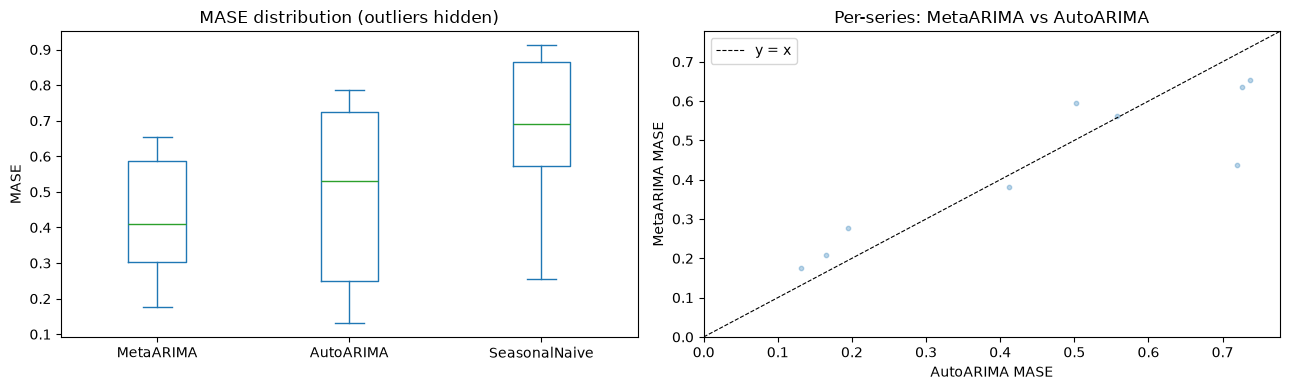

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Boxplot
ax = axes[0]
errors[MODEL_NAMES].plot.box(ax=ax, showfliers=False)
ax.set_ylabel("MASE")
ax.set_title("MASE distribution (outliers hidden)")

# Scatter: MetaARIMA vs AutoARIMA per series
ax = axes[1]
ax.scatter(errors["AutoARIMA"], errors["MetaARIMA"], alpha=0.3, s=10)
lim = max(errors[["AutoARIMA", "MetaARIMA"]].quantile(0.98))
ax.plot([0, lim], [0, lim], "k--", lw=0.8, label="y = x")
ax.set_xlabel("AutoARIMA MASE")
ax.set_ylabel("MetaARIMA MASE")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_title("Per-series: MetaARIMA vs AutoARIMA")
ax.legend()

plt.tight_layout()
plt.show()

## 5. Inspect selected ARIMA configurations

MetaARIMA selects a different ARIMA order for each series. Let's look at the distribution of selected configurations.

In [14]:
config_counts = pd.Series(selected_configs).value_counts()

print(f"Unique configurations selected: {len(config_counts)}")
print(f"\nTop 10 most selected:")
config_counts.head(10)

Unique configurations selected: 7

Top 10 most selected:


ARIMA(4,1,0)(0,1,1)[12]    4
ARIMA(0,1,2)(0,0,0)[12]    1
ARIMA(0,1,2)(0,0,1)[12]    1
ARIMA(1,1,1)(0,0,1)[12]    1
ARIMA(1,1,0)(0,1,1)[12]    1
ARIMA(3,1,3)(1,1,1)[12]    1
ARIMA(4,1,0)(0,0,1)[12]    1
Name: count, dtype: int64

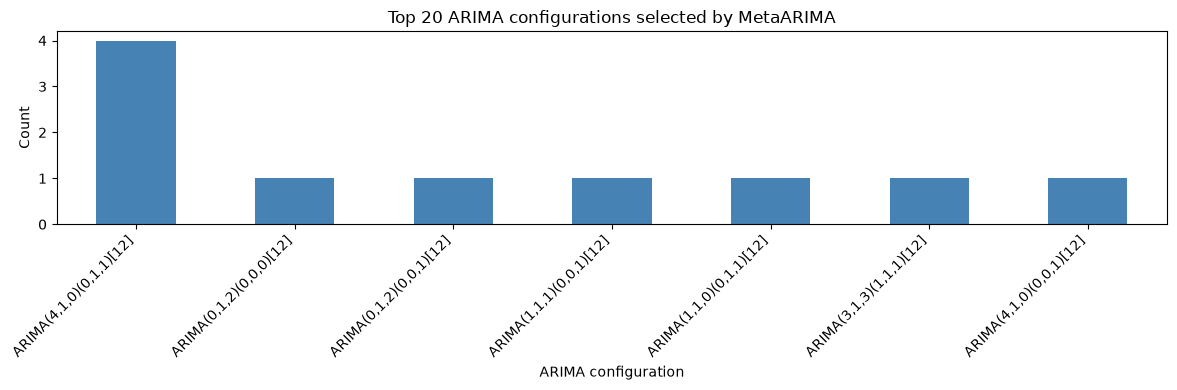

In [15]:
fig, ax = plt.subplots(figsize=(12, 4))
config_counts.head(20).plot.bar(ax=ax, color="steelblue")
ax.set_title("Top 20 ARIMA configurations selected by MetaARIMA")
ax.set_ylabel("Count")
ax.set_xlabel("ARIMA configuration")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Example forecast

Let's pick a single series and visualise the MetaARIMA and AutoARIMA forecasts side by side.

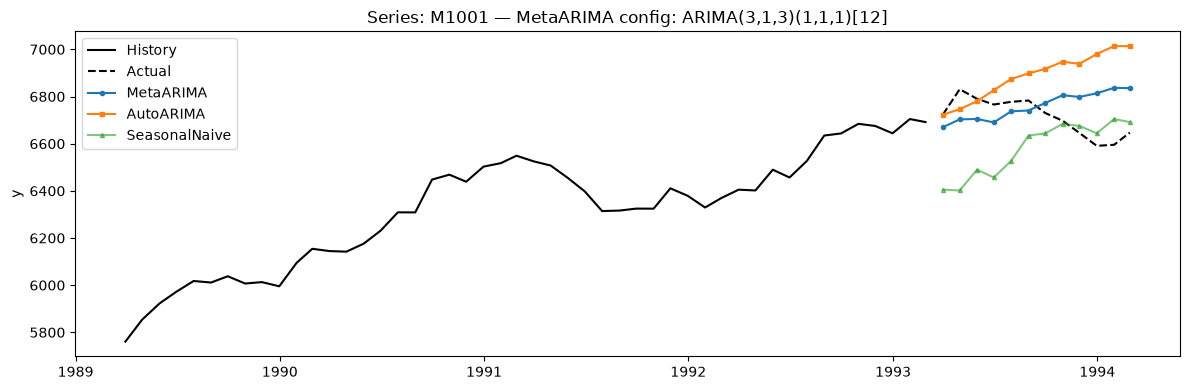

In [21]:
# Pick the first series that has results
example_uid = results_df["unique_id"].unique()[4]

ex_tr = train.query(f'unique_id == "{example_uid}"')
ex_ts = results_df.query(f'unique_id == "{example_uid}"')

fig, ax = plt.subplots(figsize=(12, 4))

# Last 48 observations of training data
history = ex_tr.tail(48).set_index("ds")
ax.plot(history.index, history["y"], color="black", label="History")

# Actuals
fc = ex_ts.set_index("ds")
ax.plot(fc.index, fc["y"], color="black", linestyle="--", label="Actual")

# Forecasts
ax.plot(fc.index, fc["MetaARIMA"], label="MetaARIMA", marker="o", markersize=3)
ax.plot(fc.index, fc["AutoARIMA"], label="AutoARIMA", marker="s", markersize=3)
ax.plot(fc.index, fc["SeasonalNaive"], label="SeasonalNaive", marker="^", markersize=3, alpha=0.6)

ax.set_title(f"Series: {example_uid} — MetaARIMA config: {selected_configs.get(example_uid, '?')}")
ax.set_ylabel("y")
ax.legend()
plt.tight_layout()
plt.show()

---

## Summary

| Method | Description |
|--------|-------------|
| **MetaARIMA** | Meta-learned shortlist (25 configs) → successive halving → best ARIMA by AICc |
| **AutoARIMA** | Stepwise search over the full ARIMA space |